In [1]:
!pip install --quiet scikit-learn

In [2]:
%cd ..

/Users/danorel/Workspace/Education/University/NYU/Research/xeda


In [3]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv('.env'))

True

In [4]:
import random
import chromadb
import copy
import json
import typing as t
import pandas as pd
import numpy as np
import uuid
import pathlib
import s3fs
import openai

from dagster import EnvVar
from sklearn.metrics.pairwise import cosine_similarity
from time import time
from tqdm import tqdm

from pipeline.resources import S3FSResource
from pipeline.solid.pipeline_annotator import annotate_pipeline
from pipeline.solid.utils.model_manager import ModelManager
from pipeline.solid.utils.pipelines.pipeline_precalculated_sets import PipelineWithPrecalculatedSets
from typings.pipeline import OperatorRequestData


from constants import (
    AWS_ACCESS_KEY_ID,
    AWS_SECRET_ACCESS_KEY,
    AWS_S3_ENDPOINT_URL,
    AWS_S3_REGION_NAME,
    AWS_S3_BUCKET_NAME,
    AWS_S3_USE_SSL,
    GROUPS_CSV_PATH,
    OPENAI_API_KEY,
    VECTOR_STORE_COLLECTION,
    VECTOR_STORE_HOST,
    VECTOR_STORE_PORT,
    UNIVERSAL_POLICY_NAME
)
from typings.pipeline import Pipeline
from pipeline.solid.pipeline_sampler import next_pipeline_iter
from utils.s3 import pull_keras_model
from utils.vector_store import ChromaDBVectorStore, MilvusVectorStore, make_document_sampler

2024-04-22 15:50:53.419124: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Preparing dataset

In [5]:
vector_store = MilvusVectorStore(
    host=VECTOR_STORE_HOST, 
    port=VECTOR_STORE_PORT,
    collection_name=VECTOR_STORE_COLLECTION
)

In [6]:
fs = s3fs.S3FileSystem(
    key=AWS_ACCESS_KEY_ID,
    secret=AWS_SECRET_ACCESS_KEY,
    endpoint_url=AWS_S3_ENDPOINT_URL,
    use_ssl=AWS_S3_USE_SSL,
    client_kwargs={"region_name": AWS_S3_REGION_NAME},
)

In [7]:
database_pipeline_cache = {}
database_pipeline_cache["galaxies"] = PipelineWithPrecalculatedSets(
    "sdss",
    ["galaxies"],
    discrete_categories_count=10,
    min_set_size=10,
    exploration_columns=[
        "galaxies.u",
        "galaxies.g",
        "galaxies.r",
        "galaxies.i",
        "galaxies.z",
        "galaxies.petroRad_r",
        "galaxies.redshift",
    ],
    id_column="galaxies.objID",
)

In [8]:
model_manager = ModelManager(database_pipeline_cache["galaxies"], models = {
    "set": pull_keras_model(
        s3fs=fs,
        bucket_name=AWS_S3_BUCKET_NAME,
        policy_name=UNIVERSAL_POLICY_NAME,
        model_name="set_actor",
    ),
    "operation": pull_keras_model(
        s3fs=fs,
        bucket_name=AWS_S3_BUCKET_NAME,
        policy_name=UNIVERSAL_POLICY_NAME,
        model_name="operation_actor",
    ),
    "set_op_counters": None,
})

In [9]:
groups_df = pd.read_csv(GROUPS_CSV_PATH)

In [10]:
def get_text_embedding(input_text: str) -> list:
    """
    This function takes a stringified text and returns the corresponding embedding.
    
    Args:
    input_text (str): The text to encode into an embedding.
    
    Returns:
    list: A list of floats representing the text embedding.
    """
    try:
        # Choose an appropriate model for embedding
        model = "text-embedding-ada-002"  # You can choose other models depending on your requirements

        # Generate the embedding
        response = openai.embeddings.create(model=model, input=input_text)
        
        # Retrieve and return the embedding vector
        embedding = response.data[0].embedding
        return embedding

    except openai.OpenAIError as e:
        print(f"OpenAI API error occurred: {e}")
    except Exception as e:
        print(f"An error occurred: {e}")

In [11]:
def node_to_encoding(node, only_annotation = True):
    if only_annotation:
        annotation = node.get('annotation')
    else:
        annotation = node
    if annotation == None:
        return ''
    node_encoding = []
    for k, v in annotation.items():
        if isinstance(v, dict):
            for key in v:
                node_encoding.append(f"{k}_{key} = {v[key]}")
        else:
            node_encoding.append(f"{k} = {v}")
    return ', '.join(node_encoding)


def pipeline_to_splits(pipeline: Pipeline) -> t.List[Pipeline]:
    splits = []
    pipeline_encoding = []
    for node in reversed(pipeline):
        node_encoding = node_to_encoding(node)
        pipeline_encoding.append(node_encoding)
        splits.append(copy.deepcopy(pipeline_encoding))
    return splits


def pipeline_to_embedding(pipeline: Pipeline):
    pipeline_splits = pipeline_to_splits(pipeline)
    pipeline_payload = (
        [str(uuid.uuid4()) for _ in range(len(pipeline_splits))],
        [json.dumps(copy.deepcopy(pipeline)) for _ in range(len(pipeline_splits))],
        [';'.join(pipeline_split) for pipeline_split in pipeline_splits]
    )
    return pipeline_payload

In [12]:
def fetch_pipelines():
    for annotated_file in fs.glob('xeda/annotated_pipelines/*.json'):
        with fs.open(annotated_file, 'r') as f:
            annotated_pipeline = json.load(f)
            yield annotated_pipeline


def insert_pipelines(vector_store, refresh: bool = True):
    if not refresh:
        print("Skipping refresh of vector storage")
        return
    for annotated_pipeline in fetch_pipelines():
        (
            pipeline_ids,
            pipeline_documents,
            pipeline_sentences
        ) = pipeline_to_embedding(annotated_pipeline)
        pipeline_embeddings = [
            get_text_embedding(sentence) 
            for sentence in pipeline_sentences
        ]
        pipeline_valid_indices = [
            i
            for i, doc in enumerate(pipeline_documents)
            if len(doc) <= 65535
        ]
        if len(pipeline_valid_indices) > 0:
            vector_store.insert(
                ids=[pipeline_ids[i] for i in pipeline_valid_indices],
                documents=[pipeline_documents[i] for i in pipeline_valid_indices],
                embeddings=[pipeline_embeddings[i] for i in pipeline_valid_indices],
            )

insert_pipelines(vector_store, refresh=False)

Skipping refresh of vector storage


### Experiments

In [15]:
from concurrent.futures import ThreadPoolExecutor


def explore_pipeline(partial_pipeline: Pipeline, database_pipeline_cache, k: int):
    # This is a stub to simulate pipeline exploration.
    # In a real scenario, this would involve applying transformations or decisions based on an RL model.

    partial_latest_node = partial_pipeline[-1]
    partial_latest_request_data = partial_latest_node.get("requestData")
    
    terminal_request_data = OperatorRequestData(**partial_latest_request_data)
    terminal_pipeline = partial_pipeline.copy()
    
    for i in range(len(partial_pipeline), len(partial_pipeline) + k):
        try:
            start_time = time()
            terminal_node, terminal_request_data = next_pipeline_iter(
                database_pipeline_cache,
                model_manager,
                terminal_request_data
            )
            print(f"Made step in {time() - start_time}s")
            terminal_pipeline.append(terminal_node)
        except ValueError:
            print(f"Unexpectedly exited from pipeline generation on step {i}. Saving pipeline as it is...")
            break
    
    return annotate_pipeline(groups_df, terminal_pipeline)


def compute_embeddings(pipeline):
    ids, documents, sentences = pipeline_to_embedding(pipeline)
    embeddings = [get_text_embedding(sentence) for sentence in sentences]
    return np.array(embeddings).mean(axis=0)


def similarity(emb1, emb2, type_of_similarity):
    if type_of_similarity == 'cosine':
        return np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
    elif type_of_similarity == 'euclidian':
        return np.linalg.norm(emb1 - emb2)
    elif type_of_similarity == 'manhattan':
        return np.abs(emb1 - emb2).sum()
    else:
        raise NotImplementedError("Unknown type of similarity")


def result_to_pipeline(result: dict):
    return json.loads(result.get('document'))


def make_experiment(vector_store, pipeline_index: int, pipeline_id: str, type_of_similarity: str, k: int):
    print(f"Starting an experiment with k='{k}' exploration steps and type_of_similarity='{type_of_similarity}'")
    start_time = time()

    partial_pipeline = result_to_pipeline(vector_store.get(pipeline_id))
    partial_embedding = compute_embeddings(partial_pipeline)
    
    terminal_pipeline = explore_pipeline(partial_pipeline, database_pipeline_cache, k=k)
    terminal_embedding = compute_embeddings(terminal_pipeline)
    
    partial_search_results = vector_store.search(embedding=partial_embedding, k=1000)

    min_pipeline, max_pipeline = result_to_pipeline(partial_search_results[0]), result_to_pipeline(partial_search_results[-1])
    min_embedding = compute_embeddings(min_pipeline)
    max_embedding = compute_embeddings(max_pipeline)

    min_to_terminal_similarity = similarity(terminal_embedding, min_embedding, type_of_similarity)
    max_to_terminal_similarity = similarity(terminal_embedding, max_embedding, type_of_similarity)

    print(f"Finished an experiment with k='{k}' exploration steps and type_of_similarity='{type_of_similarity}' in {time() - start_time}s")
    
    return {
        "partial_pipeline_id": pipeline_id,
        "min_to_terminal_similarity": min_to_terminal_similarity,
        "max_to_terminal_similarity": max_to_terminal_similarity,
    }


def experiment_metadata(experiment, type_of_similarity, k):
    r = {
        "experiment": experiment + 1,
        "exploration_steps": k,
        "type_of_similarity": type_of_similarity
    }
    return r


def run_single_experiment(args):
    try:
        experiment, vector_store, sampled_pipeline_index, sampled_pipeline_id, types_of_similarity, exploration_steps = args
        results = []
        for k in range(*exploration_steps):
            for type_of_similarity in types_of_similarity:
                experiment_config = (type_of_similarity, k)
                results.append({
                    **experiment_metadata(
                        experiment,
                        *experiment_config
                    ),
                    **make_experiment(
                        vector_store,
                        sampled_pipeline_index, 
                        sampled_pipeline_id,
                        *experiment_config
                    )
                })
        return results
    except Exception as e:
        print(f"Error in experiment {args[0]}: {e}")  # Log the error and experiment details
        return []  # Return an empty list or some error indicator


def run_experiments(n: int = 1000, types_of_similarity: list = ['cosine'], exploration_steps: tuple = (3, 6), max_workers: int = 4):
    pipeline_sampler = make_document_sampler(vector_store)

    # Prepare arguments for each experiment
    experiments_args = []
    for experiment in range(n):
        sampled_pipeline_index, sampled_pipeline_id = pipeline_sampler()
        experiments_args.append((experiment, vector_store, sampled_pipeline_index, sampled_pipeline_id, types_of_similarity, exploration_steps))
    
    # Run experiments in parallel
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(tqdm(executor.map(run_single_experiment, experiments_args), total=n))

    # Collect all results into a single DataFrame
    experiments = pd.DataFrame([item for sublist in results for item in sublist])
    return experiments

In [ ]:
experiments_path = 'data/experiments_50_k-1-7.csv'

if pathlib.Path(experiments_path).exists():
    experiments_df = pd.read_csv(experiments_path)
else:
    experiments_df = run_experiments(
        n=50,
        types_of_similarity=['manhattan', 'cosine', 'euclidian'],
        exploration_steps=(1, 8),
        max_workers=4
    )

Starting an experiment with k='1' exploration steps and type_of_similarity='manhattan'Starting an experiment with k='1' exploration steps and type_of_similarity='manhattan'

Starting an experiment with k='1' exploration steps and type_of_similarity='manhattan'
Starting an experiment with k='1' exploration steps and type_of_similarity='manhattan'


  0%|                                                                      | 0/50 [00:00<?, ?it/s]

1/1 [==============================] - 0s 33ms/step
[0.08225223 0.02321358 0.13885237 0.10773632 0.09761137 0.19017736
 0.09253015 0.11633133 0.10796879 0.04332649]
[0.33666029102753703, 0.09501373828414632, 0.5683259706883167, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
1/1 [==============================] - 0s 43ms/step
[0.04292053 0.06477405 0.0388247  0.09049357 0.02454767 0.05008492
 0.03861947 0.0311286  0.06136245 0.03921935 0.12626145 0.10977872
 0.08332574 0.0706317  0.07128489 0.0567422 ]
[0.07403823655803941, 0.11173572937995517, 0.0, 0.0, 0.04234492713533772, 0.0, 0.0, 0.0, 0.0, 0.06765367326304952, 0.21780196602229043, 0.0, 0.1437375394261439, 0.121840216219945, 0.12296698921033948, 0.09788072278489945]
by_superset
Inference has finished: 0.17644119262695312s
1/1 [==============================] - 0s 266ms/step
[0.06782877 0.03451586 0.19643202 0.06213154 0.05559159 0.14172051
 0.06242856 0.10081303 0.19389482 0.0846433 ]
[0.16285427920644782, 0.08287126123240948, 0.471625744782696

In [ ]:
experiments_success_condition = (experiments_df['max_to_terminal_similarity'] < experiments_df['min_to_terminal_similarity'])
experiments_df['explanation_satisfied'] = experiments_success_condition
experiments_df.to_csv('data/experiments.csv', index=False)

### Visualizations

In [18]:
!pip install --quiet matplotlib seaborn

In [19]:
import matplotlib.pyplot as plt
import math
import seaborn as sns

In [20]:
visualization_df = experiments_df.copy()

In [21]:
visualization_df

,experiment,k,type_of_similarity,partial_pipeline_id,min_to_terminal_similarity,max_to_terminal_similarity,explanation_satisfied
0,1,3,manhattan,5ae3bd07-b37a-46ab-b0e1-cc0e4c9d373c,7.327087,7.725554,False
1,1,3,cosine,f23f0801-5147-495b-97bc-89989e770143,0.984627,0.953968,True
2,1,3,euclidian,3c4d2a8f-e970-4dae-b22f-93e42e327787,0.288044,0.285160,True
3,1,4,manhattan,c11c4095-84b3-4ac7-aff6-2ecb9826910a,6.950720,7.966908,False
4,1,4,cosine,3b90e110-32c5-4f29-8a0a-9d525621cd76,0.950633,0.974942,False
...,...,...,...,...,...,...,...
445,50,4,cosine,3958f553-5419-4104-a318-964489516e53,0.964478,0.956394,True
446,50,4,euclidian,eb397166-4358-42be-9ca3-29461642e3b6,0.207536,0.303541,False
447,50,5,manhattan,3958f553-5419-4104-a318-964489516e53,5.845199,7.993009,False
448,50,5,cosine,89024319-8e7d-40b9-a95d-b298076fcb06,0.987344,0.950653,True


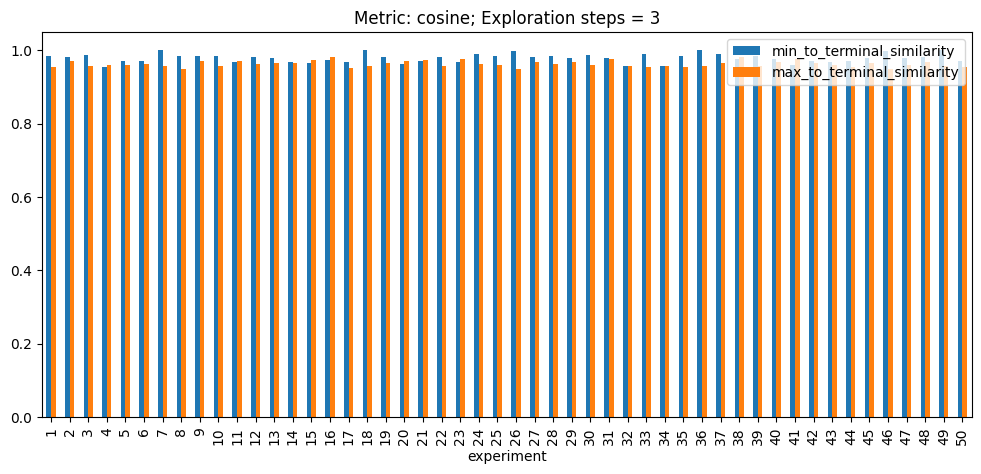

In [22]:
cosine_3k_df = visualization_df.loc[(visualization_df['type_of_similarity'] == 'cosine') & (visualization_df['k'] == 3)][['experiment', 'min_to_terminal_similarity', 'max_to_terminal_similarity']]

plot = cosine_3k_df.plot(
    kind='bar',
    x='experiment', 
    y=['min_to_terminal_similarity', 'max_to_terminal_similarity'],
    title='Metric: cosine; Exploration steps = 3',
    figsize=(12, 5)
)
plt.show()

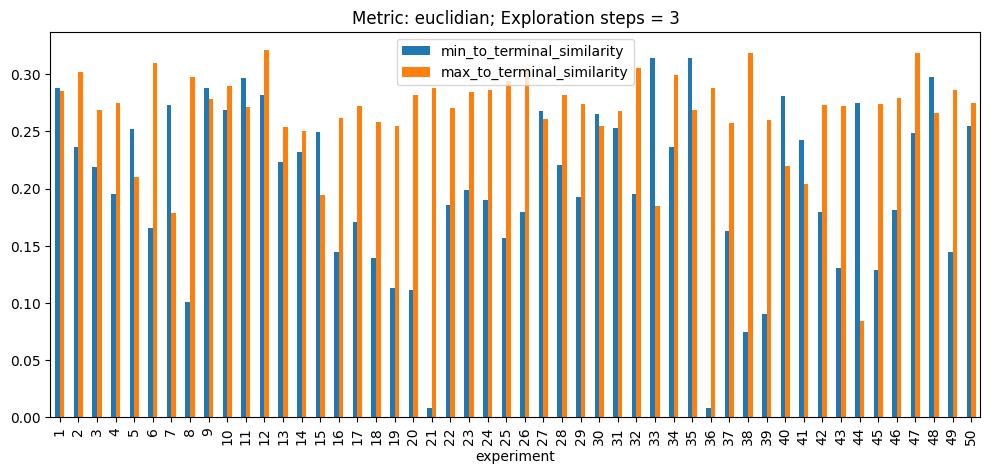

In [23]:
euclidian_3k_df = visualization_df.loc[
    (visualization_df['type_of_similarity'] == 'euclidian') & 
    (visualization_df['k'] == 3)
][['experiment', 'min_to_terminal_similarity', 'max_to_terminal_similarity']]

plot = euclidian_3k_df.plot(
    kind='bar', 
    x='experiment', 
    y=['min_to_terminal_similarity', 'max_to_terminal_similarity'],
    title='Metric: euclidian; Exploration steps = 3',
    figsize=(12, 5)
)
plt.show()

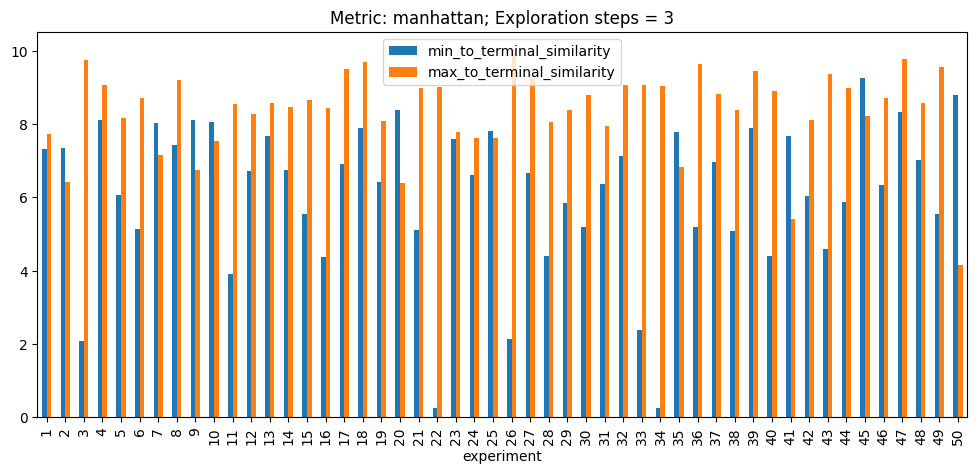

In [24]:
manhattan_3k_df = visualization_df.loc[
    (visualization_df['type_of_similarity'] == 'manhattan') & 
    (visualization_df['k'] == 3)
][['experiment', 'min_to_terminal_similarity', 'max_to_terminal_similarity']]

plot = manhattan_3k_df.plot(
    kind='bar', 
    x='experiment', 
    y=['min_to_terminal_similarity', 'max_to_terminal_similarity'],
    title='Metric: manhattan; Exploration steps = 3',
    figsize=(12, 5)
)
plt.show()

In [25]:
k_values = visualization_df['k'].unique()

In [26]:
for k in k_values:
    euclidian_df = visualization_df.loc[(visualization_df['type_of_similarity'] == 'euclidian') & (visualization_df['k'] == k)]
    amount_of_success_experiments = len(euclidian_df.loc[euclidian_df['explanation_satisfied'] == True])
    amount_of_total_experiments = len(set(euclidian_df['experiment'].values))
    euclidian_success_percentage = round((amount_of_success_experiments / amount_of_total_experiments) * 100, 2)
    print(f"Euclidian success cases for {k} exploration steps: {euclidian_success_percentage}%")

Euclidian success cases for 3 exploration steps: 28.0%
Euclidian success cases for 4 exploration steps: 24.0%
Euclidian success cases for 5 exploration steps: 28.0%


In [27]:
for k in k_values:
    cosine_df = visualization_df.loc[(visualization_df['type_of_similarity'] == 'cosine') & (visualization_df['k'] == k)]
    amount_of_success_experiments = len(cosine_df.loc[cosine_df['explanation_satisfied'] == True])
    amount_of_total_experiments = len(set(cosine_df['experiment'].values))
    cosine_success_percentage = round((amount_of_success_experiments / amount_of_total_experiments) * 100, 2)
    print(f"Cosine success cases for {k} exploration steps: {cosine_success_percentage}%")

Cosine success cases for 3 exploration steps: 80.0%
Cosine success cases for 4 exploration steps: 72.0%
Cosine success cases for 5 exploration steps: 62.0%


In [28]:
for k in k_values:
    manhattan_df = visualization_df.loc[(visualization_df['type_of_similarity'] == 'manhattan') & (visualization_df['k'] == k)]
    amount_of_success_experiments = len(manhattan_df.loc[manhattan_df['explanation_satisfied'] == True])
    amount_of_total_experiments = len(set(manhattan_df['experiment'].values))
    manhattan_success_percentage = round((amount_of_success_experiments / amount_of_total_experiments) * 100, 2)
    print(f"Manhattan success cases for {k} exploration steps: {manhattan_success_percentage}%")

Manhattan success cases for 3 exploration steps: 20.0%
Manhattan success cases for 4 exploration steps: 14.0%
Manhattan success cases for 5 exploration steps: 18.0%


### Plots

In [29]:
# Grouping data by type_of_similarity and k, and calculate success rates
success_rates = experiments_df.groupby(['type_of_similarity', 'k']).agg(
    total_experiments=('explanation_satisfied', 'count'),
    successful_experiments=('explanation_satisfied', 'sum')
).reset_index()

success_rates['success_rate'] = (success_rates['successful_experiments'] / success_rates['total_experiments']) * 100

# Displaying the calculated success rates
success_rates

,type_of_similarity,k,total_experiments,successful_experiments,success_rate
0,cosine,3,50,40,80.0
1,cosine,4,50,36,72.0
2,cosine,5,50,31,62.0
3,euclidian,3,50,14,28.0
4,euclidian,4,50,12,24.0
5,euclidian,5,50,14,28.0
6,manhattan,3,50,10,20.0
7,manhattan,4,50,7,14.0
8,manhattan,5,50,9,18.0


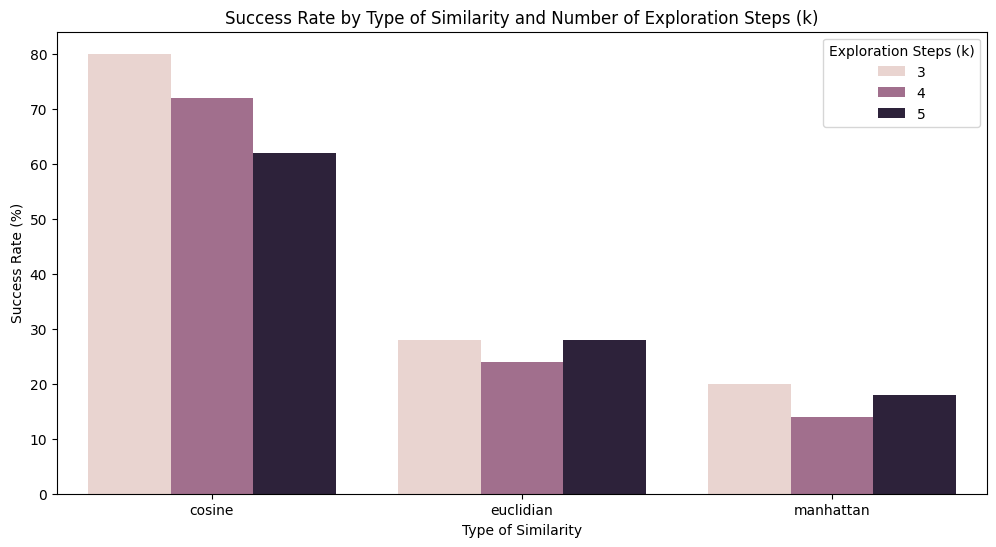

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Setting up the plot
plt.figure(figsize=(12, 6))
sns.barplot(data=success_rates, x='type_of_similarity', y='success_rate', hue='k')
plt.title('Success Rate by Type of Similarity and Number of Exploration Steps (k)')
plt.xlabel('Type of Similarity')
plt.ylabel('Success Rate (%)')
plt.legend(title='Exploration Steps (k)')
plt.show()

/var/folders/rp/5xgdthw53sn2b8gbxv7b0r240000gp/T/ipykernel_26243/4259157348.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cv_data, x='type_of_similarity', y='Coefficient_of_Variation', palette='viridis')


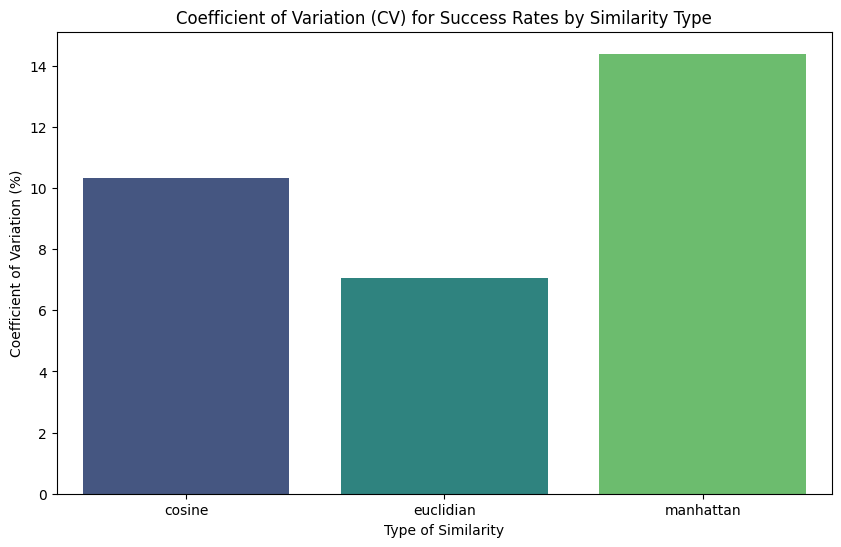

In [31]:
import numpy as np

# Re-calculating the Coefficient of Variation (CV) for each type of similarity
cv_data = success_rates.groupby('type_of_similarity')['success_rate'].apply(
    lambda x: np.std(x) / np.mean(x) * 100  # CV as a percentage
).reset_index().rename(columns={'success_rate': 'Coefficient_of_Variation'})

# Plotting the Coefficient of Variation
plt.figure(figsize=(10, 6))
sns.barplot(data=cv_data, x='type_of_similarity', y='Coefficient_of_Variation', palette='viridis')
plt.title('Coefficient of Variation (CV) for Success Rates by Similarity Type')
plt.xlabel('Type of Similarity')
plt.ylabel('Coefficient of Variation (%)')
plt.show()

### Best configuration

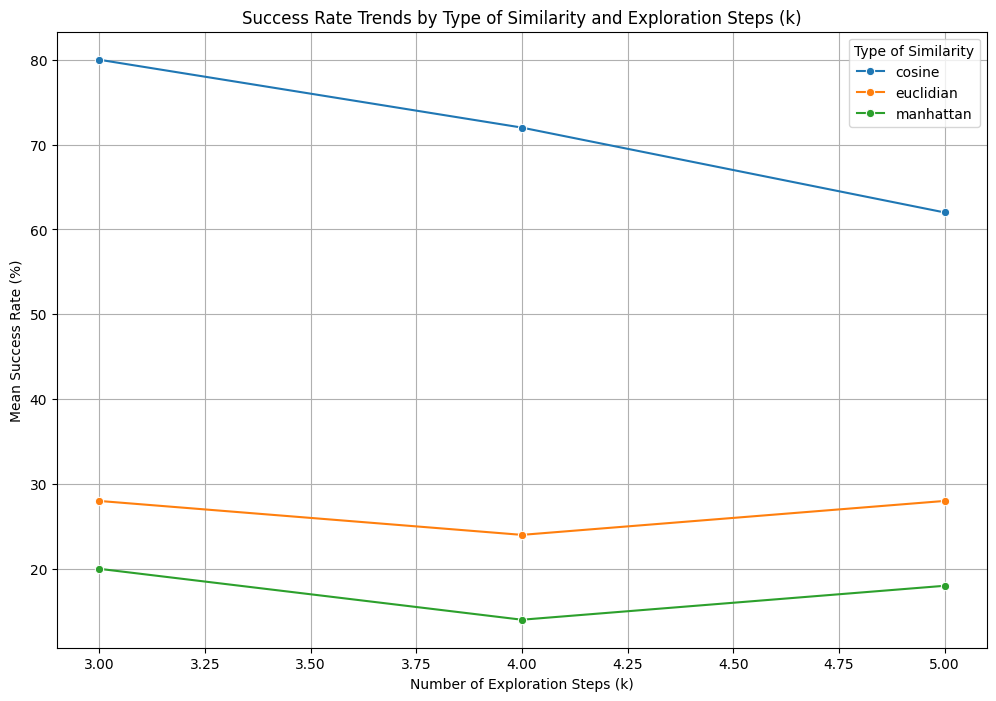

In [32]:
# Grouping the data by type of similarity and k, summarizing success rates
success_summary = experiments_df.groupby(['type_of_similarity', 'k']).agg(
    mean_success_rate=('explanation_satisfied', lambda x: x.mean() * 100)
).reset_index()

# Plotting the success rate trends for each type of similarity across different k
plt.figure(figsize=(12, 8))
sns.lineplot(data=success_summary, x='k', y='mean_success_rate', hue='type_of_similarity', marker='o')
plt.title('Success Rate Trends by Type of Similarity and Exploration Steps (k)')
plt.xlabel('Number of Exploration Steps (k)')
plt.ylabel('Mean Success Rate (%)')
plt.legend(title='Type of Similarity')
plt.grid(True)
plt.show()

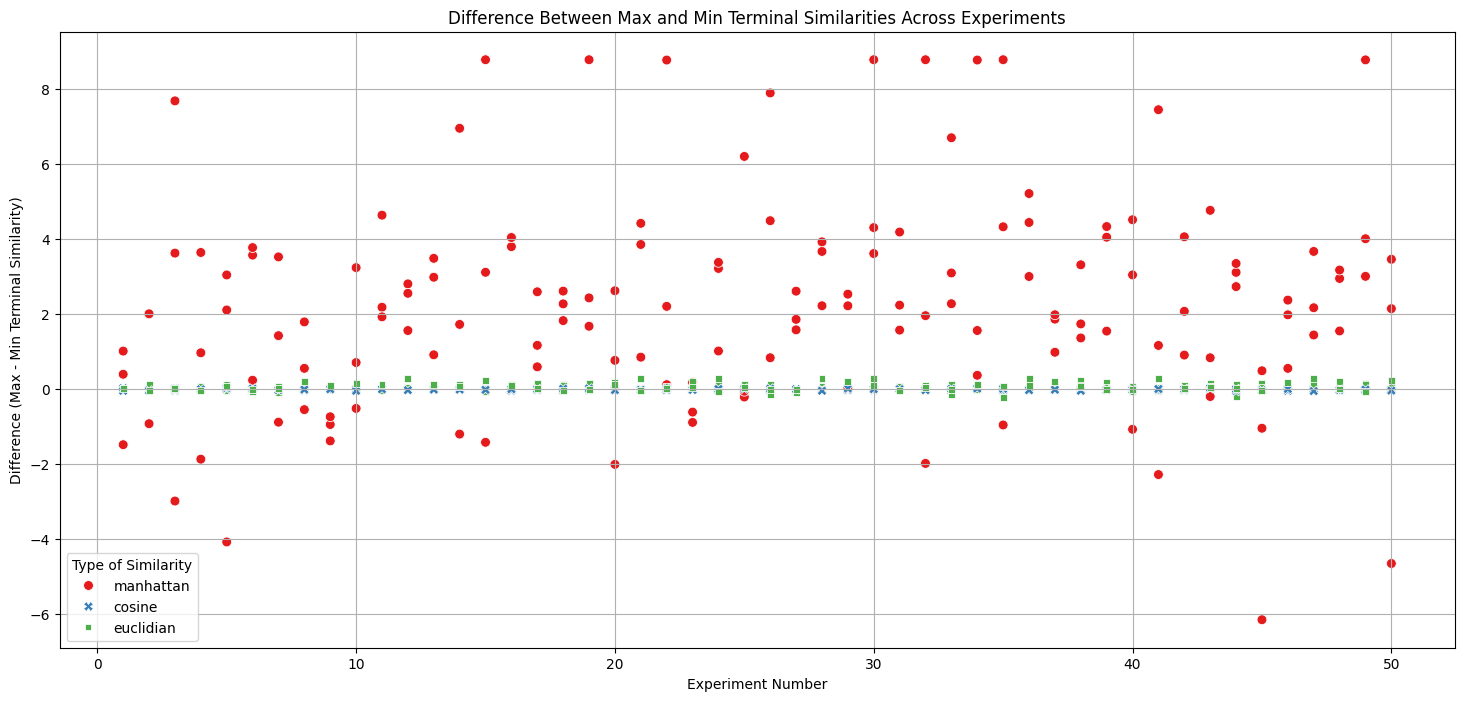

In [33]:
experiments_df['similarity_difference'] = experiments_df['max_to_terminal_similarity'] - experiments_df['min_to_terminal_similarity']

plt.figure(figsize=(18, 8))
sns.scatterplot(data=experiments_df, x='experiment', y='similarity_difference', hue='type_of_similarity', style='type_of_similarity', palette='Set1', s=50)
plt.title('Difference Between Max and Min Terminal Similarities Across Experiments')
plt.xlabel('Experiment Number')
plt.ylabel('Difference (Max - Min Terminal Similarity)')
plt.legend(title='Type of Similarity')
plt.grid(True)
plt.show()